## Ejercicio de Programación 5 - Reconstrucción de imagen usando Gradiente Conjugado


1. Construir matriz de transformación A
2. Implementar algoritmo de gradiente conjugado no lineal
3. Calcular función objetivo chi-cuadrado
4. Aplicar regularización si es necesario
5. Reconstruir imagen y visualizar resultados
6. Comparar con imagen verdadera y evaluar convergencia

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

#imports
import numpy as np

# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_uv_coverage


In [3]:
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA1.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T03:00:00",
    "utc_end": "2023-11-21T06:00:00",
    "step_min": 2,
    "n_freqs": 100,
    'bandwidth': None, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 1,
    "max_offset_deg": 1.0, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ , times_sec = visibilities_simulation(SKA_LOW_AA1)



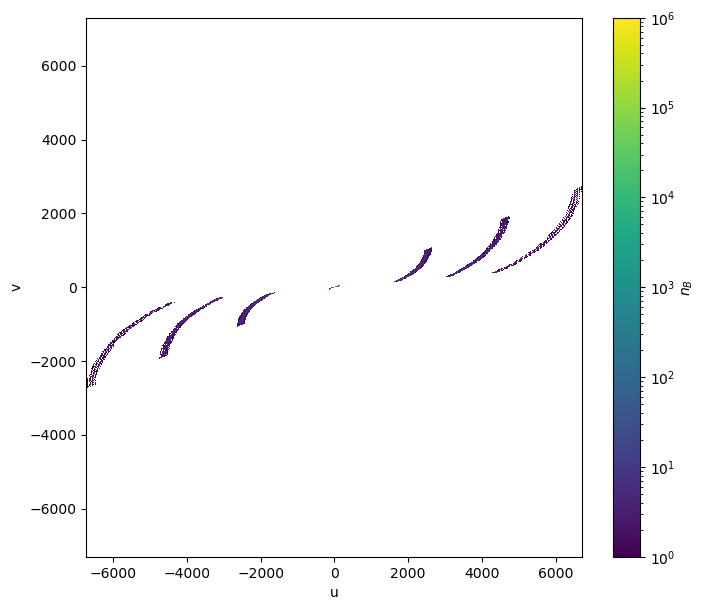

In [4]:
plot_uv_coverage_2(uvw, bins=512)

In [5]:
from modules.gridder import grid_visibilities, get_grid_config

N = 512

grid_config = get_grid_config(V, uvw_lambda, N, baselines_enu, oversampling_factor=0.7, frequencies=frequencies)
grid_config.keys()

dict_keys(['V', 'uvw_lambda', 'du', 'dv', 'Dmax', 'frequencies', 'oversampling_factor', 'baselines', 'Npix', 'pixel_size_image'])

In [6]:
VG, WG = grid_visibilities(grid_config=grid_config, mode="numpy")

Backend a utilizar: numpy


In [7]:
cellsize = grid_config["pixel_size_image"]
coords = (np.arange(N) - N//2) * cellsize
l_grid, m_grid = np.meshgrid(coords, coords)

l_grid = np.asarray(l_grid)
m_grid = np.asarray(m_grid)

u = uvw_lambda[...,0]
v = uvw_lambda[...,1]

u = np.asarray(u).ravel()
v = np.asarray(v).ravel()
V = np.asarray(V).ravel()

In [8]:
import matplotlib.pyplot as plt
from modules.conj_grad import conjugate_gradient_imaging

I_cg = conjugate_gradient_imaging(
    Vobs=V,
    u=u,
    v=v,
    l=l_grid,
    m=m_grid,
    tol=1e-5,
    maxiter=30
)

plt.imshow(I_cg, origin="lower")
plt.colorbar(label="Jy/beam")
plt.title("Imagen reconstruida (CG)")


: 